 # Numerical Dissipation and Dispersion



 When solving hyperbolic PDEs numerically, two important errors appear:



 ### Numerical Dissipation



 Numerical dissipation causes the amplitude of the wave to decay over time.



 $$

 |G| < 1

 $$



 The scheme artificially damps the solution.



 Example:

 FTBS (upwind scheme)



 ---



 ### Numerical Dispersion



 Numerical dispersion causes waves to travel at incorrect speeds.



 $$

 \phi_{num} \neq \phi_{exact}

 $$



 The phase of the wave becomes incorrect even if the amplitude is preserved.



 Example:

 Central differencing schemes with RK time integration.



 ---



 In this tutorial we compare:



 - FTBS  → dissipative scheme   (Amplitude decreases)

 - RK2 + CD2 → dispersive scheme (Different wave numbers travel at different speeds because of this we observe oscillations)



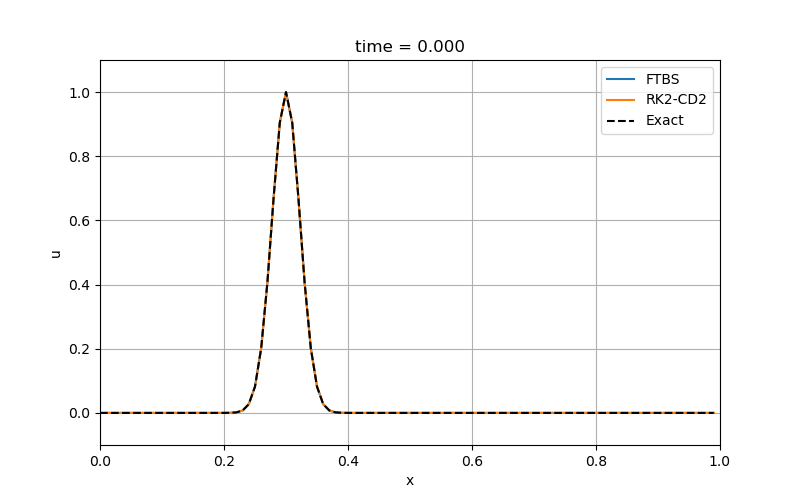

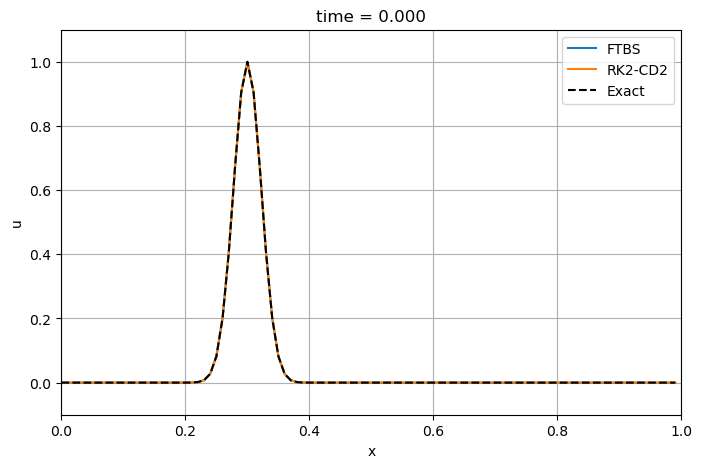

In [14]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

plt.rcParams["animation.html"] = "jshtml"

# =====================================================
# Domain
# =====================================================
L = 1.0
N = 100

dx = L/N
x = np.linspace(0,L,N,endpoint=False)

# =====================================================
# Gaussian pulse
# =====================================================
x0 = 0.3
alpha = 1000

def gaussian(x):
    return np.exp(-alpha*(x-x0)**2)

u0 = gaussian(x)

# =====================================================
# Parameters
# =====================================================
c = 1.0
CFL = 0.5

dt = CFL*dx/c

T = 1.0
nt = int(T/dt)

# =====================================================
# FTBS scheme
# =====================================================
def FTBS(u):
    return u - CFL*(u - np.roll(u,1))

# =====================================================
# Central derivative
# =====================================================
def CD2(u):
    return (np.roll(u,-1)-np.roll(u,1))/(2*dx)

# =====================================================
# RK2-CD2
# =====================================================
def RK2_CD2(u):

    def RHS(u):
        return -c*CD2(u)

    k1 = RHS(u)
    k2 = RHS(u + dt*k1)

    return u + dt*0.5*(k1+k2)

# =====================================================
# Simulation
# =====================================================
u_ftbs = u0.copy()
u_rk2  = u0.copy()

history_ftbs = [u_ftbs.copy()]
history_rk2  = [u_rk2.copy()]

for i in range(nt):

    u_ftbs = FTBS(u_ftbs)
    u_rk2  = RK2_CD2(u_rk2)

    history_ftbs.append(u_ftbs.copy())
    history_rk2.append(u_rk2.copy())

history_ftbs = np.array(history_ftbs)
history_rk2 = np.array(history_rk2)

# =====================================================
# Exact solution
# =====================================================
def exact_solution(x,t):

    x_shift = (x - c*t) % L
    return gaussian(x_shift)

# =====================================================
# Animation
# =====================================================
fig,ax = plt.subplots(figsize=(8,5))

line_ftbs, = ax.plot([],[],label="FTBS")
line_rk2,  = ax.plot([],[],label="RK2-CD2")
line_ex,   = ax.plot([],[],'k--',label="Exact")

ax.set_xlim(0,L)
ax.set_ylim(-0.1,1.1)

ax.set_xlabel("x")
ax.set_ylabel("u")
ax.legend()
ax.grid()

def update(frame):

    t = frame*dt

    line_ftbs.set_data(x,history_ftbs[frame])
    line_rk2.set_data(x,history_rk2[frame])
    line_ex.set_data(x,exact_solution(x,t))

    ax.set_title(f"time = {t:.3f}")

    return line_ftbs,line_rk2,line_ex

ani = FuncAnimation(
    fig,
    update,
    frames=len(history_ftbs),
    interval=40,
    blit=False
)

from IPython.display import HTML
# HTML(ani.to_jshtml())
ani.save("wave_propagation.gif", writer="pillow", fps=20)
from IPython.display import Image
Image("wave_propagation.gif")

 From the above animation, you can observe that
 - FTBS  → dissipative scheme   (Amplitude decreases)

 - RK2 + CD2 → dispersive scheme (Different wave numbers travel at different speeds because of this we observe oscillations)


 # Limitations of Von Neumann Stability Analysis



 Von Neumann stability analysis is a powerful tool for studying numerical schemes, but it has several important limitations.



 ---



 ## 1. Assumes Linear PDEs



 Von Neumann analysis assumes the governing equation is linear with

 constant coefficients.



 $$

 u_t + c u_x = 0

 $$



 For nonlinear equations such as



 $$

 u_t + u u_x = 0

 $$



 or the Euler equations, the analysis does not strictly apply because

 Fourier modes interact with each other.



 ---



 ## 2. Requires Periodic or Infinite Domains



 The method assumes the solution can be expanded in Fourier modes:



 $$

 u_i = e^{i k x_i}

 $$



 This assumption is valid only when the domain is



 - periodic, or

 - effectively infinite.



 In bounded domains with boundary conditions, stability behaviour

 may differ.



 ---



 ## 3. Ignores Boundary Conditions



 Von Neumann analysis studies the behavior of interior points only.



 Boundary conditions can introduce instabilities even if the

 interior scheme is stable.



 ---



 ## 4. Only Measures Linear Error Growth



 The analysis measures how a small perturbation evolves:



 $$

 \epsilon_i^n = G^n e^{ikx_i}

 $$



 It does not capture nonlinear error mechanisms such as:



 - shock formation

 - nonlinear instabilities

 - aliasing errors



 ---



 ## 5. Stability Does Not Guarantee Accuracy



 Even if



 $$

 |G| \le 1

 $$



 the solution may still suffer from



 - numerical diffusion

 - numerical dispersion



 Therefore stability does not imply that the numerical solution is accurate.



 ---



 ## 6. High-Frequency Modes Dominate the Analysis



 Von Neumann analysis studies the response of each Fourier mode.

 High-frequency modes (large $k\Delta x$) often determine stability,

 but they may not represent the dominant physics of the problem.



 ---



 ## Key Insight



 Von Neumann analysis is best viewed as a necessary but not sufficient

 condition for stability.



 In practice, additional analysis and numerical experiments are required

 to fully understand the behavior of a scheme.



  ## Equivalent Wavenumber (Modified Wavenumber)- Capabilities and Limitations



 When a numerical scheme approximates spatial derivatives, it does not

 reproduce the exact derivative. Instead, it behaves as if the wave number

 has been modified.



 For a wave



 $$

 u(x,t) = e^{i(kx-\omega t)}

 $$



 the exact derivative is



 $$

 \frac{\partial u}{\partial x} = i k u

 $$



 Numerical discretization produces



 $$

 \frac{\partial u}{\partial x} \approx i k^* u

 $$



 where



 $ k^* $ is called the **equivalent wavenumber**.



 If



 $$

 k^* = k

 $$



 the scheme is exact.



 Differences between $k^*$ and $k$ produce numerical errors:



 - Real part of $k^*$ → dispersion error

 - Imaginary part of $k^*$ → dissipation



 Equivalent Wavenumber for FTBS



 FTBS discretization:



 $$

 \frac{\partial u}{\partial x}

 \approx

 \frac{u_i-u_{i-1}}{\Delta x}

 $$



 Assume Fourier mode



 $$

 u_i = e^{i k x_i}

 $$



 Then



 $$

 u_{i-1} = e^{-ik\Delta x} u_i

 $$



 Substitute:



 $$

 \frac{u_i-u_{i-1}}{\Delta x}

 =

 \frac{1-e^{-ik\Delta x}}{\Delta x}u_i

 $$



 Compare with exact derivative



 $$

 \frac{\partial u}{\partial x} = i k^* u

 $$



 Therefore



 $$

 i k^* = \frac{1-e^{-ik\Delta x}}{\Delta x}

 $$



 and



 $$

 k^* =

 \frac{-i(1-e^{-ik\Delta x})}{\Delta x}

 $$



 Expanding



 $$

 k^* =

 \frac{\sin(k\Delta x)}{\Delta x}

 +

 i\frac{1-\cos(k\Delta x)}{\Delta x}

 $$



 Real part → numerical dispersion

 Imaginary part → numerical dissipation



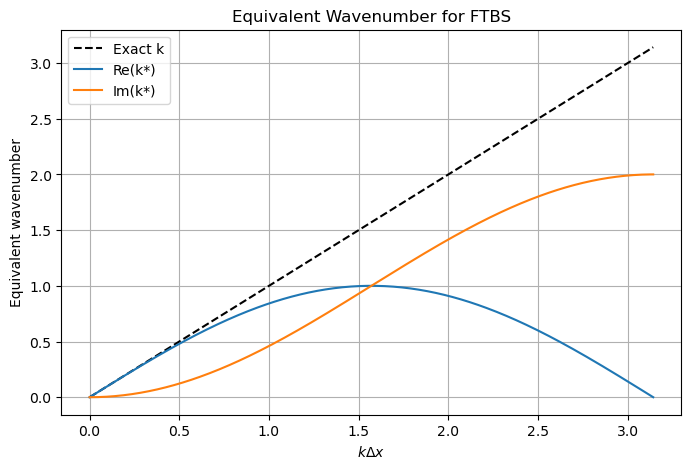

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# dimensionless wavenumber
theta = np.linspace(0,np.pi,400)

# equivalent wavenumber for FTBS
k_real = np.sin(theta)
k_imag = 1 - np.cos(theta)

# exact wavenumber
k_exact = theta

plt.figure(figsize=(8,5))

plt.plot(theta,k_exact,'k--',label="Exact k")
plt.plot(theta,k_real,label="Re(k*)")
plt.plot(theta,k_imag,label="Im(k*)")

plt.xlabel(r"$k\Delta x$")
plt.ylabel("Equivalent wavenumber")
plt.title("Equivalent Wavenumber for FTBS")

plt.legend()
plt.grid()

plt.show()

Theoritical $k_{eq}$ vs simulation $k_{eq}$ for backward in space 

In [16]:
# %%
import numpy as np

# ==============================
# Domain
# ==============================
L = 2*np.pi
N = 256

dx = L/N
x = np.linspace(0, L, N, endpoint=False)

# ==============================
# Single Fourier mode
# ==============================
k_true = 3
u = np.sin(k_true*x)

# ==============================
# Backward difference derivative
# ==============================
Du = (u - np.roll(u,1))/dx

# ==============================
# FFT
# ==============================
uhat = np.fft.fft(u)
Duhat = np.fft.fft(Du)

# numerical equivalent wavenumber
k_eq_fft = -1j * Duhat / uhat

# ==============================
# Extract dominant Fourier mode
# ==============================
mode = np.argmax(np.abs(uhat))

k_num = k_eq_fft[mode]

# ==============================
# Theoretical equivalent wavenumber
# ==============================
theta = k_true*dx

k_eq_theory = (-1j*(1-np.exp(-1j*theta)))/dx

# ==============================
# Print comparison
# ==============================
print("First-order Backward difference scheme:\n")
print("True wavenumber:")
print(k_true)

print("\nNumerical equivalent wavenumber (simulation):")
print("Real =", k_num.real)
print("Imag =", k_num.imag)

print("\nTheoretical equivalent wavenumber:")
print("Real =", k_eq_theory.real)
print("Imag =", k_eq_theory.imag)

# ==============================
# Error
# ==============================
error = np.abs(k_num - k_eq_theory)

print("\nAbsolute error between simulation and theory:")
print(error)

First-order Backward difference scheme:

True wavenumber:
3

Numerical equivalent wavenumber (simulation):
Real = 2.997289966921007
Imag = -0.11039672655566948

Theoretical equivalent wavenumber:
Real = 2.9972899669210076
Imag = -0.11039672655566982

Absolute error between simulation and theory:
5.551115123125783e-16


Theoritical $k_{eq}$ vs simulation $k_{eq}$ for central difference scheme in space 

In [17]:
# %%
import numpy as np

# ==============================
# Domain
# ==============================
L = 2*np.pi
N = 256

dx = L/N
x = np.linspace(0, L, N, endpoint=False)

# ==============================
# Single Fourier mode
# ==============================
k_true = 3
u = np.sin(k_true*x)

# ==============================
# CD2 derivative
# ==============================
Du = (np.roll(u,-1) - np.roll(u,1))/(2*dx)

# ==============================
# FFT
# ==============================
uhat = np.fft.fft(u)
Duhat = np.fft.fft(Du)

# numerical equivalent wavenumber
k_eq_fft = -1j * Duhat / uhat

# ==============================
# Extract dominant Fourier mode
# ==============================
mode = np.argmax(np.abs(uhat))

k_num = k_eq_fft[mode]

# ==============================
# Theoretical equivalent wavenumber
# ==============================
theta = k_true * dx

k_eq_theory = np.sin(theta)/dx

# ==============================
# Print comparison
# ==============================
print("Second-order Central difference scheme:")
print("True wavenumber:")
print(k_true)

print("\nNumerical equivalent wavenumber (simulation):")
print("Real =", k_num.real)
print("Imag =", k_num.imag)

print("\nTheoretical equivalent wavenumber:")
print("Real =", k_eq_theory)
print("Imag = 0")

# ==============================
# Error
# ==============================
error = np.abs(k_num.real - k_eq_theory)

print("\nAbsolute error between simulation and theory:")
print(error)

Second-order Central difference scheme:
True wavenumber:
3

Numerical equivalent wavenumber (simulation):
Real = 2.9972899669210076
Imag = -4.371988794142829e-18

Theoretical equivalent wavenumber:
Real = 2.997289966921007
Imag = 0

Absolute error between simulation and theory:
4.440892098500626e-16


# Limitations of Equivalent (Modified) Wavenumber Analysis

Equivalent wavenumber analysis is a powerful tool for understanding numerical dispersion and dissipation in spatial discretization schemes. However, it has several important limitations.

---

## 1. Valid Only for Linear Problems for Spatial or temporal operator 

The analysis assumes that the solution can be represented as a Fourier mode

$$
u(x,t) = e^{i(kx-\omega t)}
$$


## 2. Requires Periodic or Infinite Domains

Equivalent wavenumber analysis relies on Fourier expansions, which assume that the domain is

* periodic, or
* effectively infinite.

In practical simulations with boundary conditions (e.g., inflow/outflow or walls), the behavior of the scheme may differ.

---

## 3. Only Analyzes the Spatial Operator

Equivalent wavenumber analysis studies the **spatial discretization**

$$
\frac{\partial u}{\partial x}
$$

but does not include the effect of **time integration methods**.

In real simulations, the numerical behavior depends on both

* spatial discretization
* time integration scheme.

---

## 4. Assumes Smooth Solutions

The derivation assumes smooth wave-like solutions.

For problems containing

* shocks
* discontinuities
* very steep gradients

Fourier representations break down, and equivalent wavenumber analysis may not predict the true behavior of the numerical scheme.

---

## 5. Does Not Predict Nonlinear Stability

Equivalent wavenumber analysis cannot detect

* nonlinear instabilities
* spurious oscillations near shocks
* total variation growth

These phenomena require different tools such as

* TVD analysis
* entropy stability
* nonlinear stability theory.

---

## 6. Emphasizes High-Wavenumber Modes

Equivalent wavenumber analysis often focuses on large values of


$k\Delta x$


which correspond to grid-scale oscillations.

These modes are important for stability but may not represent the dominant physical structures in the solution.

---

## Key Insight

Because this analysis does not account for combined space-time analysis, we cannot make any meaningful prediction for PDEs when we use FDM or FVM. It may provides valuable insight into the behavior of numerical schemes but should not be used as the sole criterion for evaluating their performance. 
